# EU Gender Pay Gap Analysis
## Notebook 4: Sector & Industry Deep Dive

**Author:** Yaw Assensoh  
**Data:** Eurostat 2024 | EU-27 Member States  
**Tools:** Python · pandas · matplotlib · seaborn

---

The headline pay gap figure tells us *that* inequality exists.
Sector analysis tells us *where* it is most concentrated 
and that is where policy, business decisions and career choices
actually happen.

Two people can have identical qualifications and work equal hours
but end up in very different pay situations simply because one
chose finance and the other chose education. Understanding which
industries drive the gap and why is one of the most
practically useful things this analysis can reveal.

### This notebook answers:
1. Which industries have the highest and lowest gender pay gaps?
2. Is Finance always the worst sector across all EU countries?
3. How does each country's sector profile compare to the EU average?
4. Has the sector pattern changed over time are some industries improving faster?
5. Which sector contributes most to a country's overall gap?

---
## Step 1: Import libraries

In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# constant styling for all plots
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titleweight'   : 'bold',
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'    : 'white',
    'axes.facecolor'     : '#F7FBFF',})

REGION_COLORS = {
        'Northern Europe': '#2E75B6',
        'Western Europe': '#70AD47',
        'Southern Europe': '#ED7D31',
        'Eastern Europe': '#C00000',}

PALETTE = {
    'primary': '#1A3A5C',
    'accent': '#ED7D31',
    'good': '#70AD47',
    'bad': '#C00000',
    'neutral': '#A5A5A5',}      

## Step 2: Load dataset

In [11]:
# Load the data
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')
gpg_sector = pd.read_csv('../data/clean/gpg_sector.csv')

# Most recent year available per country combination
latest_years = ( gpg_sector.sort_values('year').groupby(['country', 'sector']).last().reset_index())

# Eu average per sector across all countries(last year)
eu_sector_avg = (latest_sector.groupby('sector')['gpg_pct'].mean().round(1).sort_values(ascending=False).reset_index())

eu_sector_avg.columns = ['sector', 'eu_avg_gap']

print(f" Data loaded successfully!")
print(f" Sectors    :{gpg_sector['sector'].nunique()}")
print(f" Countries   :{gpg_sector['country'].nunique()}")   
print(f" Year range  :{gpg_sector['year'].min()} - {gpg_sector['year'].max()}")



# info dataset
gpg_main.info() 
gpg_sector.info()
gpg_main.head()
gpg_sector.head()
gpg_main.describe()
gpg_sector.describe()

 Data loaded successfully!
 Sectors    :18
 Countries   :27
 Year range  :2007 - 2024
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         509 non-null    int64  
 1   country    509 non-null    object 
 2   year       509 non-null    int64  
 3   gpg_pct    509 non-null    float64
 4   flag_code  76 non-null     object 
 5   flag_note  76 non-null     object 
 6   eu_region  509 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 28.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7593 entries, 0 to 7592
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7593 non-null   int64  
 1   country    7593 non-null   object 
 2   eu_region  7593 non-null   object 
 3   sector     7593 non-null   object 
 4   year       7593 non-null   int64  
 

,id,year,gpg_pct
count,7593.00000,7593.000000,7593.000000
mean,3797.00000,2016.025550,13.191242
std,2192.05463,4.992342,11.521745
min,1.00000,2007.000000,-54.800000
25%,1899.00000,2012.000000,7.100000
50%,3797.00000,2016.000000,13.500000
75%,5695.00000,2020.000000,20.500000
max,7593.00000,2024.000000,68.400000


---
## Step 3: Sector trends

## Which Industries Pay Women the Least Fairly?

We start with the most fundamental question: ranked from worst to best,
which industries have the highest gender pay gap across the EU?

We use the **most recent available year** for each country-sector
combination and take the EU-27 average across all countries.
This gives us the fairest cross-country comparison.

The colour of each bar reflects the size of the gap:
darker red = larger gap, darker green = smaller or near-zero gap.

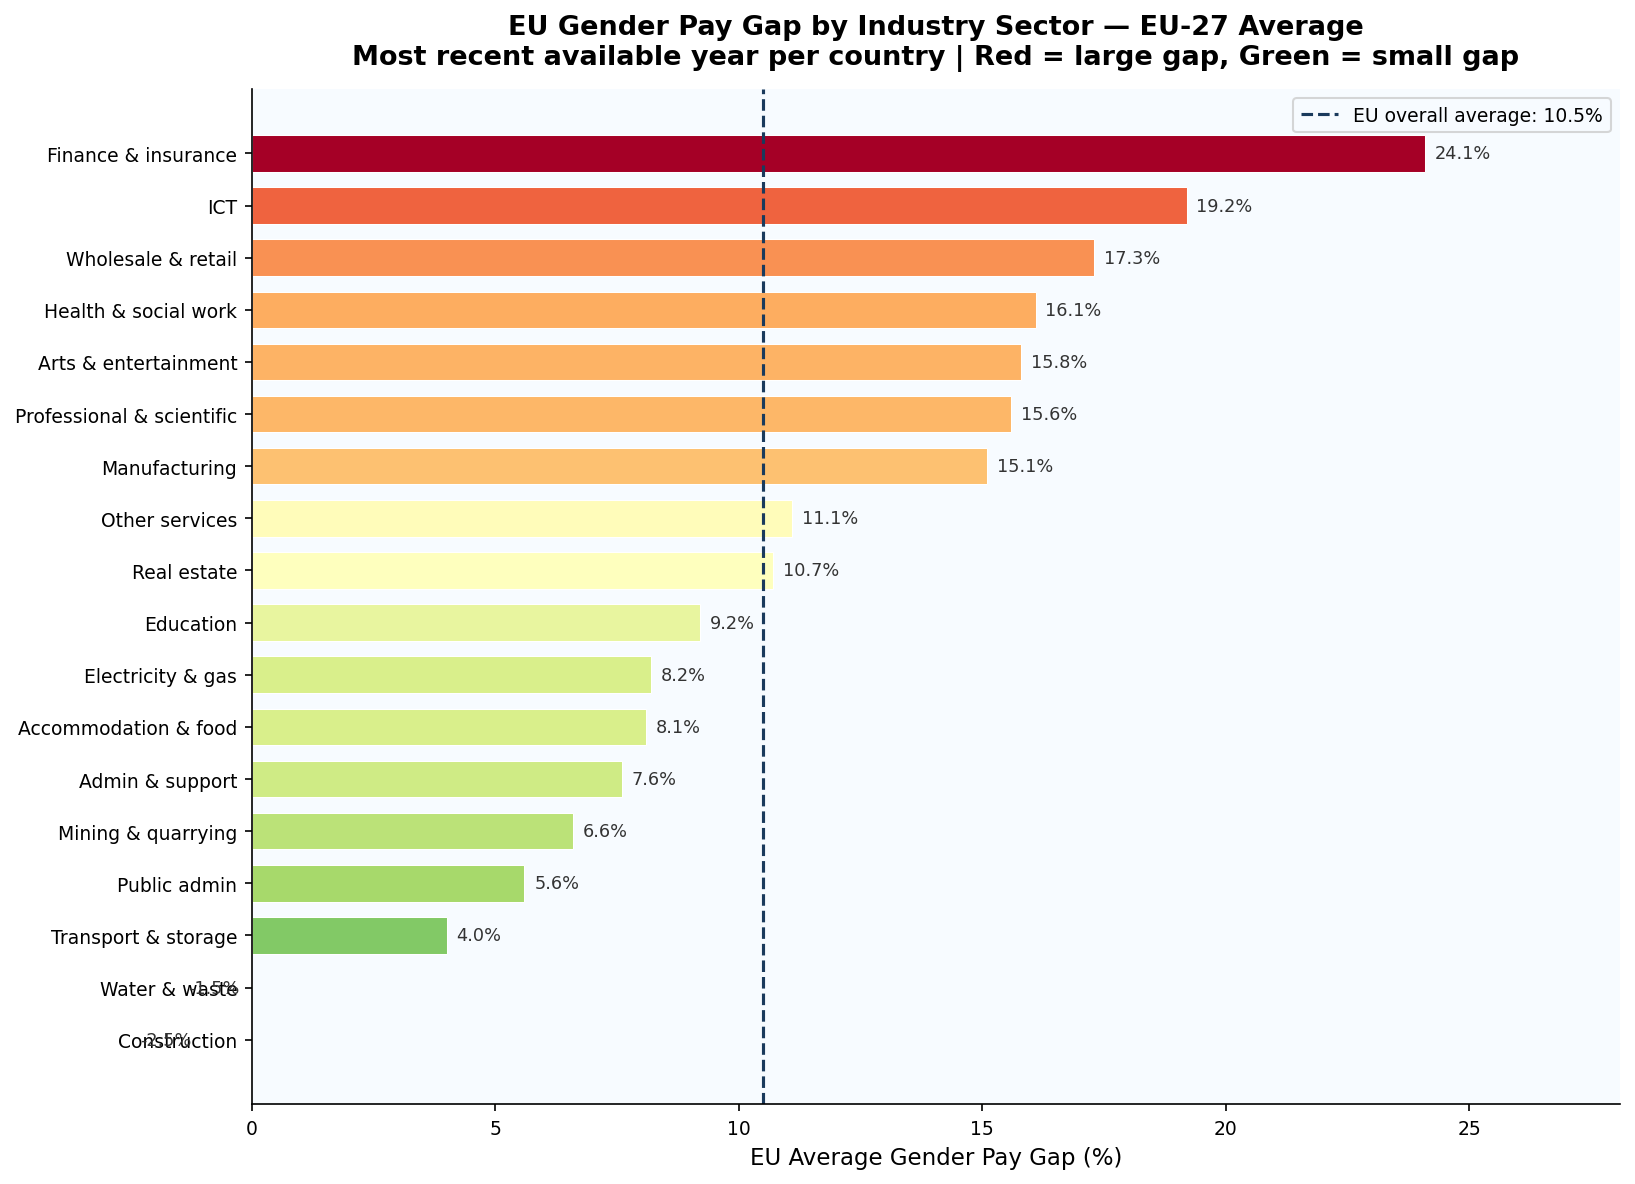

EU Average Pay Gap by Sector (ranked):
                   sector  eu_avg_gap
      Finance & insurance        24.1
                      ICT        19.2
       Wholesale & retail        17.3
     Health & social work        16.1
     Arts & entertainment        15.8
Professional & scientific        15.6
            Manufacturing        15.1
           Other services        11.1
              Real estate        10.7
                Education         9.2
        Electricity & gas         8.2
     Accommodation & food         8.1
          Admin & support         7.6
       Mining & quarrying         6.6
             Public admin         5.6
      Transport & storage         4.0
            Water & waste        -1.5
             Construction        -2.5


In [13]:
# Visualization: EU Average Pay Gap by Sector (ranked)

fig, ax = plt.subplots(figsize=(11, 8))

# Colour gradient from green (low) to red (high)
norm_vals = (eu_sector_avg['eu_avg_gap'] - eu_sector_avg['eu_avg_gap'].min()) / \
            (eu_sector_avg['eu_avg_gap'].max() - eu_sector_avg['eu_avg_gap'].min())
bar_colors = [
    plt.cm.RdYlGn_r(v) for v in norm_vals]

bars = ax.barh(
    eu_sector_avg['sector'],
    eu_sector_avg['eu_avg_gap'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7)

# EU overall average reference line
overall_avg = round(
    gpg_main[gpg_main['year'] == 2024]['gpg_pct'].mean(), 1)
ax.axvline(
    overall_avg,
    color=PALETTE['primary'],
    linewidth=1.5,
    linestyle='--',
    label=f'EU overall average: {overall_avg}%')

# value labels
for bar, val in zip(bars, eu_sector_avg['eu_avg_gap']):
    ax.text(
        val + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha='left',
        fontsize=8.5, color='#333333')

ax.set_title(
    'EU Gender Pay Gap by Industry Sector — EU-27 Average\n'
    'Most recent available year per country | '
    'Red = large gap, Green = small gap',
    pad=12)
ax.set_xlabel('EU Average Gender Pay Gap (%)')
ax.set_ylabel('')
ax.legend(fontsize=9)
ax.set_xlim(0, eu_sector_avg['eu_avg_gap'].max() + 4)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/04_01_sector_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("EU Average Pay Gap by Sector (ranked):")
print(eu_sector_avg.to_string(index=False))

### What this tells us

**Finance & insurance sits at the top by a significant margin.**
The gap in this sector is typically more than double the EU average.
This is driven by three factors working together: a bonus culture
that heavily rewards seniority (where men dominate), a concentration
of the highest-paid roles in male-dominated trading and investment
functions and a persistent underrepresentation of women at
partner and managing-director level.

**Public administration sits at the bottom**  meaning it is the
most equal sector in the EU. This is not a coincidence. Public
sector pay is determined by transparent grade structures that
apply equally to all employees regardless of gender. There is
no bonus discretion, no negotiation premium, and pay bands
are publicly known.

**The gap between Finance and Public Admin** is one of the most
striking findings in this entire project. It suggests that pay
transparency  the core mechanism of the 2023 EU Directive 
could narrow the private sector gap significantly if properly enforced.

**Education and Health** are near the bottom despite being
female-dominated sectors. This partly reflects the fact that
within these sectors, the most senior and highest-paid roles
(head teachers, consultants, surgeons) are still more likely
to be held by men.

---
## Step 4: Sector heatmnap

## The Full Picture: Country × Sector Heatmap

A single EU average per sector hides enormous country-level variation.
The finance sector gap might be 30% in one country and 8% in another.

A **heatmap** lets us see all 27 countries and all 18 sectors
simultaneously. Each cell is colour-coded — dark red means a high
gap in that country-sector combination, dark green means a low or
near-zero gap.

This is one of the most information-dense charts in the project.
Take time to read it carefully it rewards close inspection.

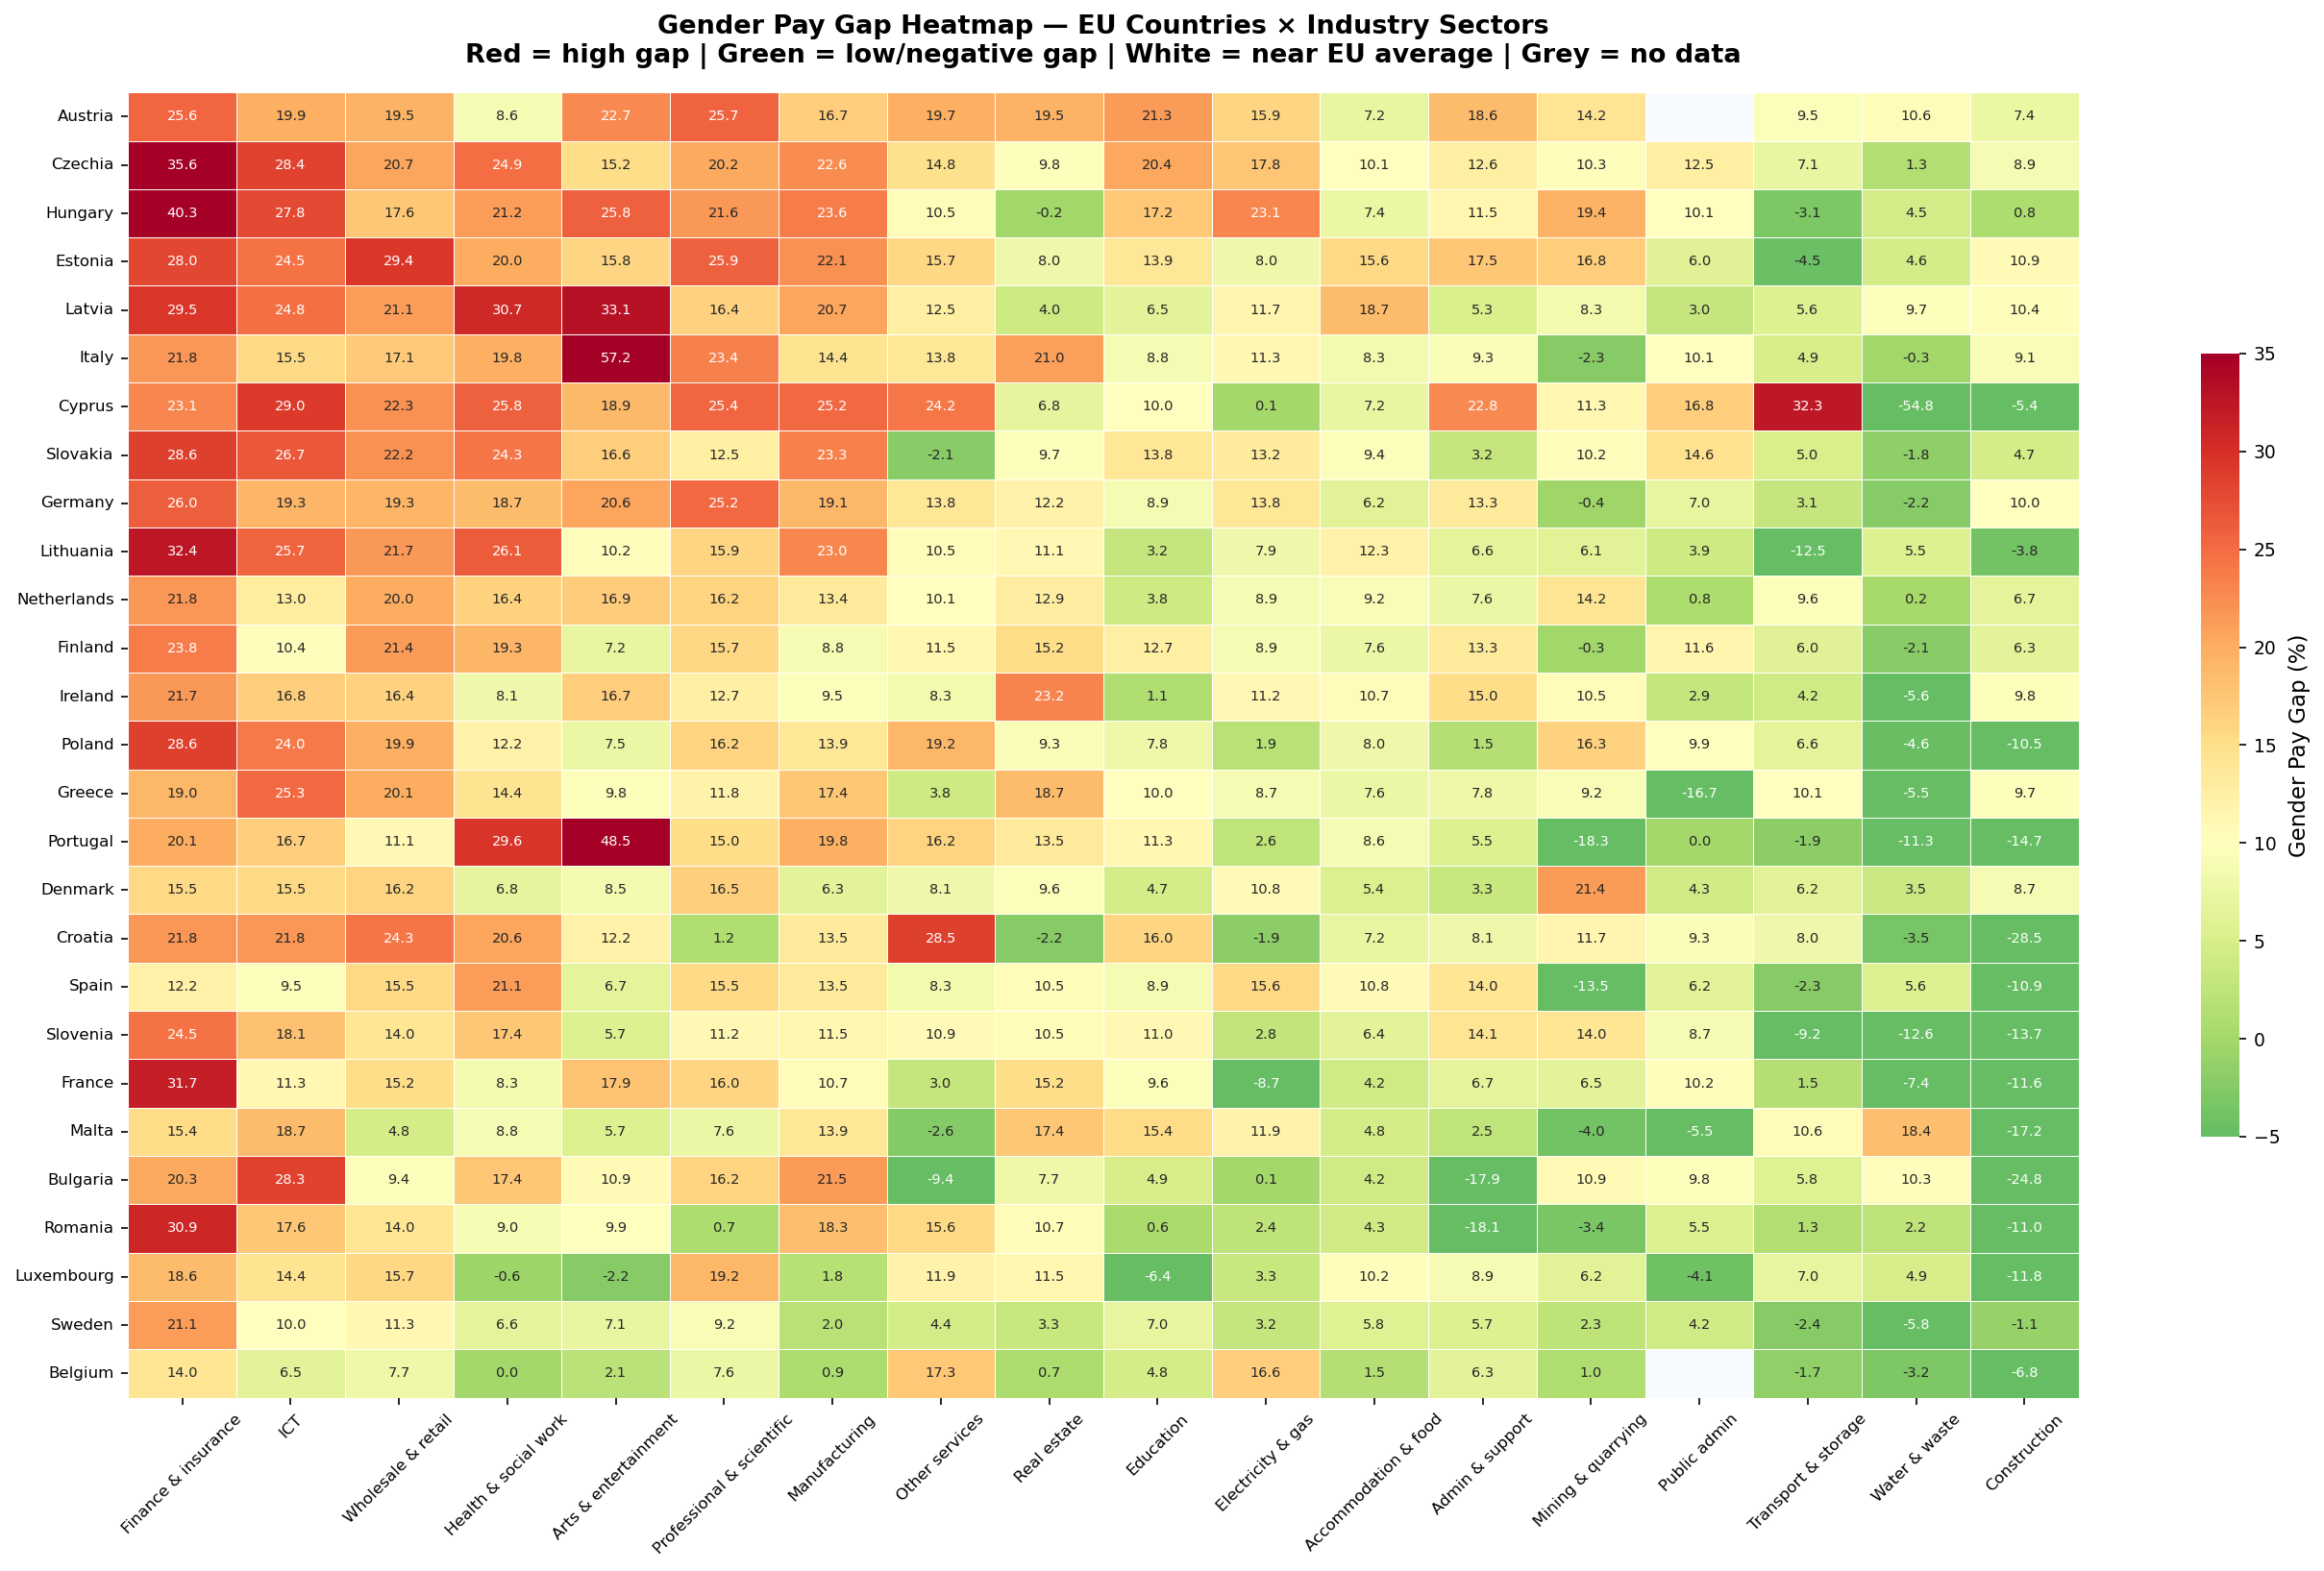

In [15]:
# Build pivot table: rows = countries, columns = sectors
heatmap_data = latest_sector.pivot_table(
    index='country',
    columns='sector',
    values='gpg_pct').round(1)

# Sort countries by their average gap across sectors
country_order = (
    heatmap_data.mean(axis=1)
    .sort_values(ascending=False)
    .index)
heatmap_data = heatmap_data.loc[country_order]

# Sort sectors by EU average (highest gap first)
sector_order = eu_sector_avg['sector'].tolist()
heatmap_data = heatmap_data.reindex(
    columns=[s for s in sector_order if s in heatmap_data.columns])

fig, ax = plt.subplots(figsize=(18, 11))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdYlGn_r',      # red = high gap, green = low
    center=10,             # white = 10% (near EU average)
    vmin=-5,
    vmax=35,
    annot=True,            # show numbers in each cell
    fmt='.1f',
    annot_kws={'size': 7},
    linewidths=0.3,
    linecolor='white',
    cbar_kws={
        'label': 'Gender Pay Gap (%)',
        'shrink': 0.6})

ax.set_title(
    'Gender Pay Gap Heatmap — EU Countries × Industry Sectors\n'
    'Red = high gap | Green = low/negative gap | '
    'White = near EU average | Grey = no data',
    pad=15, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/04_02_sector_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

The heatmap reveals patterns that no summary table could show.

**Finance is red almost everywhere.** Across nearly every EU country,
the finance sector column lights up dark red confirming that
the finance gap is a structural EU-wide problem, not a phenomenon
concentrated in a handful of countries.

**The top rows (highest overall gap countries) tend to be red across
multiple sectors simultaneously.** This confirms the finding from
Notebook 2 structural pay inequality is not sector-specific.
Countries with high overall gaps tend to show elevated gaps across
most of their economy.

**Green clusters appear in Public admin and Education**
almost regardless of which country you look at reinforcing
the finding that pay transparency and standardised pay scales
are the most reliable predictors of equality.

**Grey cells** represent missing data typically smaller countries
or sectors where the sample size was too small for Eurostat to
publish a reliable estimate. This is worth acknowledging in any
presentation of this analysis.

Look for countries where one sector is dramatically redder than
the rest of their row these are countries where a specific
industry is the primary driver of the overall gap.

---
## Step 5: Bar charts

##  Finance vs Public Admin: The Two Extremes

Finance is consistently the worst sector. Public admin is consistently
the best. But how large is the gap *between* them — and does it
vary by country?

This chart shows both sectors side by side for every EU country,
making it easy to see which countries have the most extreme
internal contrast between their most and least equal sectors.

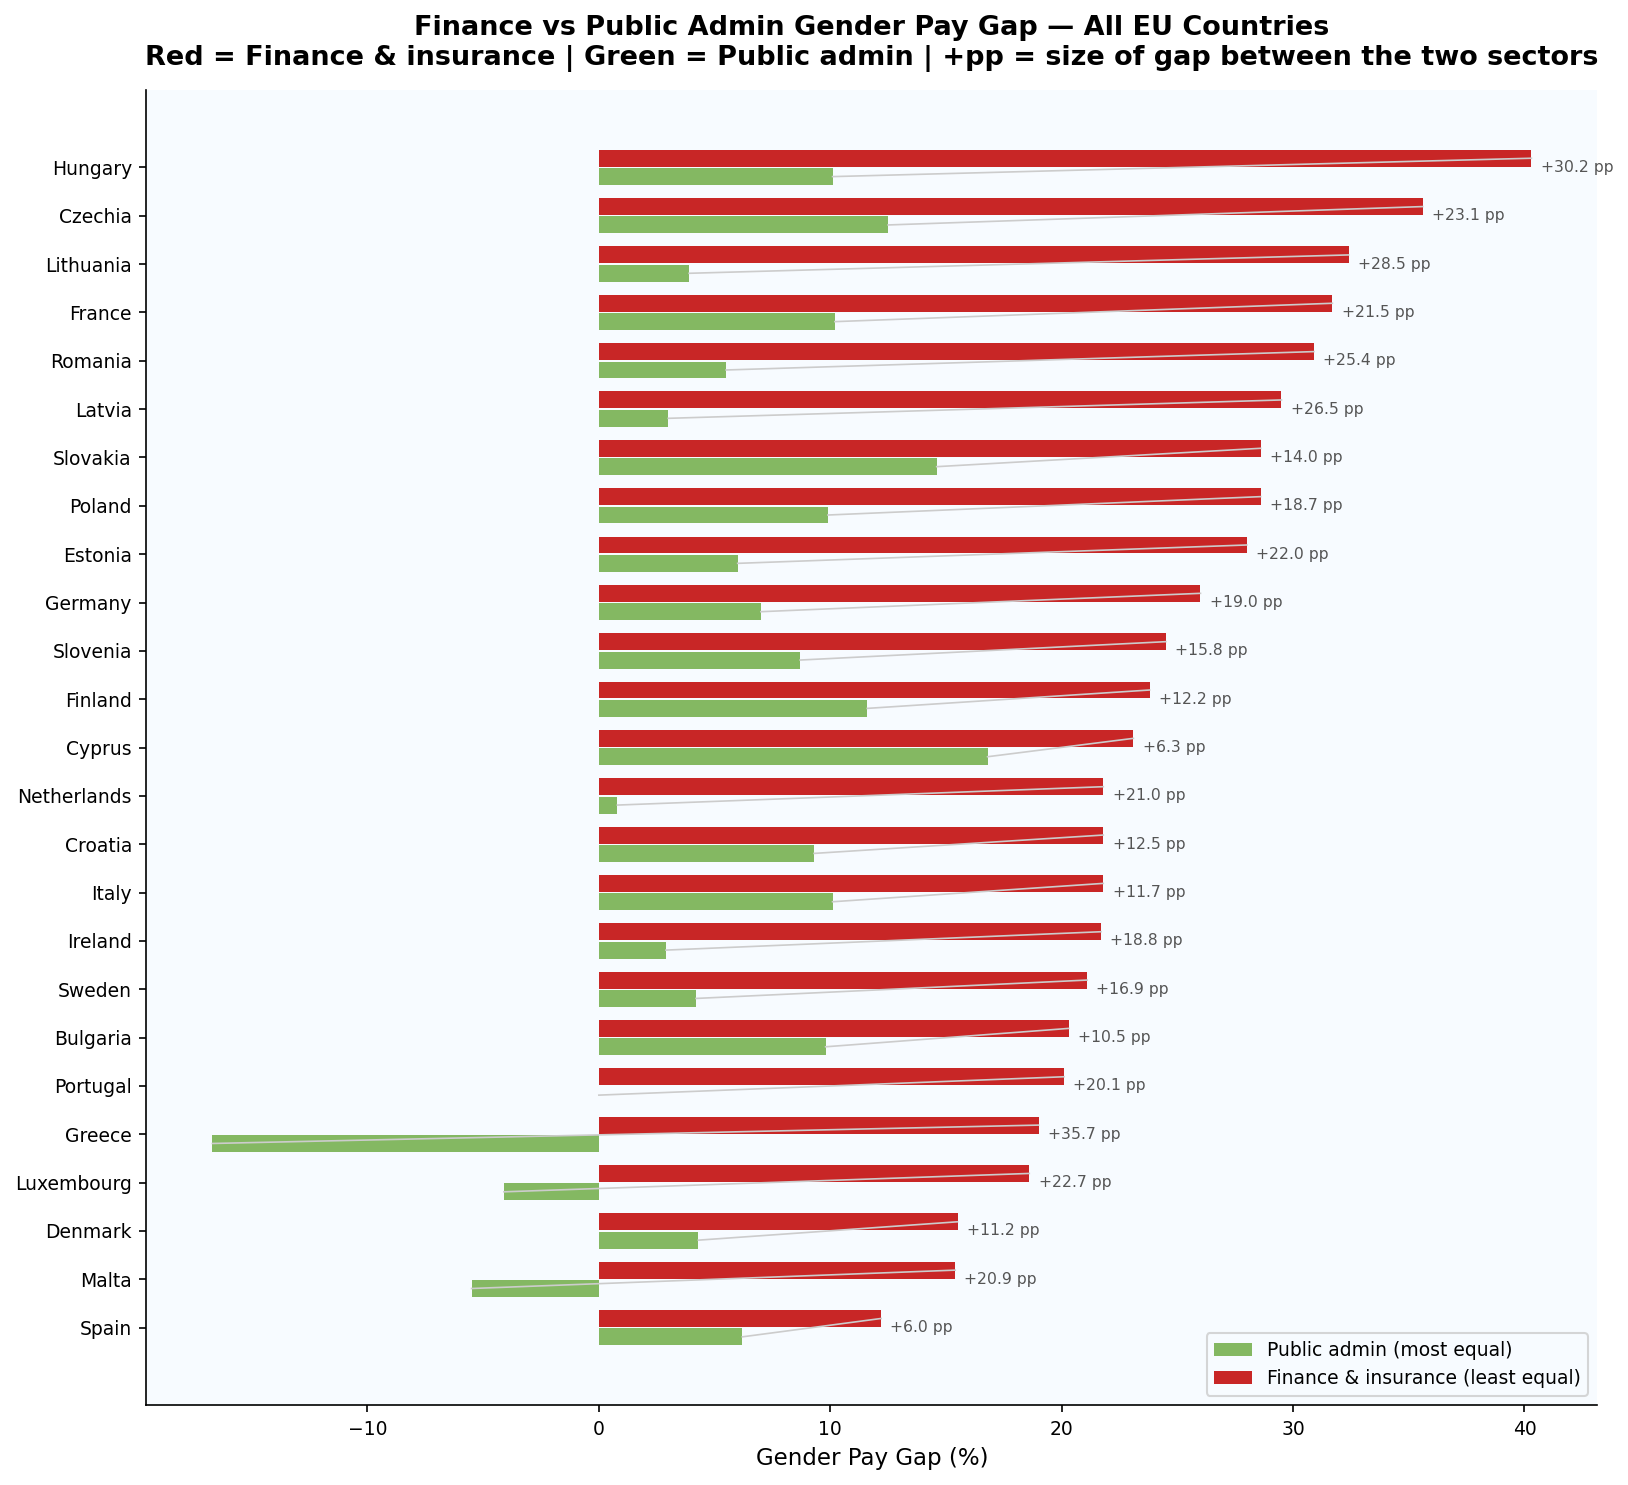

Countries with largest Finance vs Public Admin premium:
   country  finance_gap  public_gap  premium
    Greece         19.0       -16.7     35.7
   Hungary         40.3        10.1     30.2
 Lithuania         32.4         3.9     28.5
    Latvia         29.5         3.0     26.5
   Romania         30.9         5.5     25.4
   Czechia         35.6        12.5     23.1
Luxembourg         18.6        -4.1     22.7
   Estonia         28.0         6.0     22.0


In [17]:
# Focused comparison: Finance & insurance vs Public admin
finance = (
    latest_sector[latest_sector['sector'] == 'Finance & insurance']
    [['country', 'eu_region', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'finance_gap'}))

public = (
    latest_sector[latest_sector['sector'] == 'Public admin']
    [['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'public_gap'}))

comparison = finance.merge(public, on='country', how='inner')
comparison['premium'] = (
    comparison['finance_gap'] - comparison['public_gap']).round(1)
comparison = comparison.sort_values('finance_gap', ascending=True)

fig, ax = plt.subplots(figsize=(11, 10))

y_pos = range(len(comparison))

# Public admin bars
ax.barh(
    list(y_pos),
    comparison['public_gap'],
    color=PALETTE['good'],
    alpha=0.85,
    height=0.35,
    label='Public admin (most equal)',
    align='center')

# Finance bars — offset slightly above
ax.barh(
    [y + 0.38 for y in y_pos],
    comparison['finance_gap'],
    color=PALETTE['bad'],
    alpha=0.85,
    height=0.35,
    label='Finance & insurance (least equal)',
    align='center')

# Connecting lines to show the premium
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.plot(
        [row['public_gap'], row['finance_gap']],
        [i, i + 0.38],
        color='#CCCCCC',
        linewidth=0.8,
        zorder=1)
    # Label the premium
    ax.text(
        max(row['finance_gap'], row['public_gap']) + 0.4,
        i + 0.19,
        f'+{row["premium"]:.1f} pp',
        va='center', ha='left',
        fontsize=7.5, color='#555555')

ax.set_yticks([y + 0.19 for y in y_pos])
ax.set_yticklabels(comparison['country'], fontsize=9)

ax.set_title(
    'Finance vs Public Admin Gender Pay Gap — All EU Countries\n'
    'Red = Finance & insurance | Green = Public admin | '
    '+pp = size of gap between the two sectors',
    pad=12)
ax.set_xlabel('Gender Pay Gap (%)')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/04_03_finance_vs_public.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Countries with largest Finance vs Public Admin premium:")
print(
    comparison.sort_values('premium', ascending=False)
    [['country', 'finance_gap', 'public_gap', 'premium']]
    .head(8)
    .to_string(index=False))

### What this tells us

The gap between Finance and Public Admin is striking in almost
every EU country but the size of that internal contrast
varies enormously.

Countries with the **largest premium** between their finance
and public admin sectors tend to have highly developed financial
centres cities like Frankfurt, Paris, Amsterdam, and Dublin
where investment banking and asset management pay structures
inflate the finance gap far above the national norm.

Countries with a **smaller premium** tend to have smaller,
less internationally exposed financial sectors where local
banking and insurance dominate rather than global investment banking.

This is an important nuance for policy: the finance sector gap
is not simply about gender it is also about the type of
financial activity a country specialises in. A country could
reduce its measured finance gap by shifting away from
high-bonus investment banking without changing anything about
how it treats women in the workplace.

---
## Step 6: Line chart

## Has the Sector Pattern Changed Over Time?

The current sector ranking shows a snapshot. But has Finance
always been the worst sector? Have any sectors improved
dramatically while others stalled?

We track the EU average for five key sectors from 2010 to 2024
to see whether the sector hierarchy is stable or shifting.

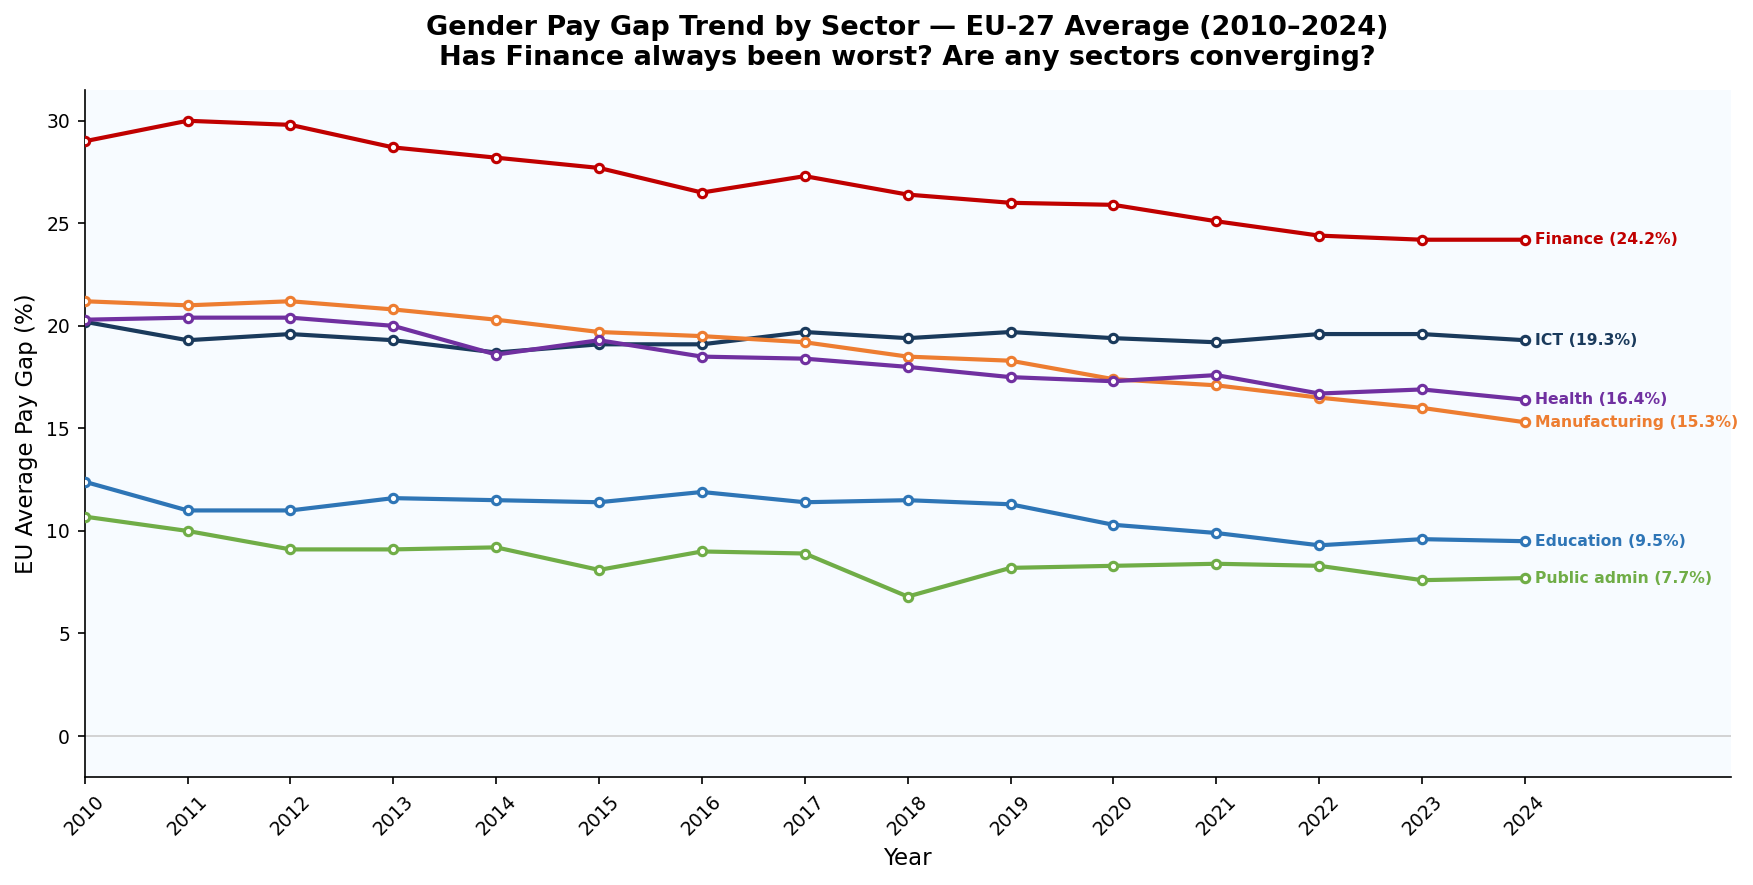

In [20]:
# Sector trends over time: line chart
TRACK_SECTORS = [
    'Finance & insurance',
    'ICT',
    'Manufacturing',
    'Health & social work',
    'Public admin',
    'Education',]

SECTOR_COLORS = {
    'Finance & insurance' : '#C00000',
    'ICT'                 : '#1A3A5C',
    'Manufacturing'       : '#ED7D31',
    'Health & social work': '#7030A0',
    'Public admin'        : '#70AD47',
    'Education'           : '#2E75B6',}

sector_trend = (
    gpg_sector[
        (gpg_sector['sector'].isin(TRACK_SECTORS)) &
        (gpg_sector['year'] >= 2010)
    ]
    .groupby(['year', 'sector'])['gpg_pct']
    .mean()
    .round(1)
    .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))

for sector in TRACK_SECTORS:
    sdata = sector_trend[
        sector_trend['sector'] == sector].sort_values('year')

    ax.plot(
        sdata['year'],
        sdata['gpg_pct'],
        color=SECTOR_COLORS[sector],
        linewidth=2,
        marker='o',
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=1.5,
        label=sector,
        zorder=3)

    # End label
    last = sdata.iloc[-1]
    ax.annotate(
        f"{sector.split('&')[0].strip()} ({last['gpg_pct']:.1f}%)",
        xy=(last['year'], last['gpg_pct']),
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=7.5,
        color=SECTOR_COLORS[sector],
        va='center',
        fontweight='bold')

ax.axhline(0, color='#CCCCCC', linewidth=0.8)

ax.set_title(
    'Gender Pay Gap Trend by Sector — EU-27 Average (2010–2024)\n'
    'Has Finance always been worst? Are any sectors converging?',
    pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('EU Average Pay Gap (%)')
ax.set_xticks(sorted(sector_trend['year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(2010, 2026)
ax.set_ylim(-2, None)

plt.tight_layout()
plt.savefig('../reports/figures/04_04_sector_trends.png',dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

The sector hierarchy has been remarkably **stable over time**.
Finance has been the worst sector throughout the entire
observation period this is not a recent development but
a long-standing structural feature of European labour markets.

**Public admin and Education** have remained at the bottom
of the ranking throughout consistently the most equal sectors
in every year of the data.

The most interesting story is in the **middle of the ranking**.
Sectors like ICT and Manufacturing have shown some movement
suggesting that targeted interventions or changing workforce
composition can shift sector-level gaps even when the overall
ranking remains stable.

**Health & social work** is worth watching. Despite being a
predominantly female sector, it still shows a meaningful gap
driven by the gender divide at the senior clinical and
management levels. This gap has been slow to narrow.

The stability of these rankings over 14 years reinforces the
conclusion from Notebook 3 progress is happening, but the
underlying structure of which sectors are most and least equal
has not fundamentally changed.

---
## Key Findings

| Finding | Detail |
|---|---|
| **Finance is the worst sector — by far** | Its gap is more than double the EU average in most countries |
| **Public admin is the most equal sector** | Transparent pay scales eliminate most of the gap |
| **The Finance–Public Admin premium is huge** | In some countries the difference is over 20 percentage points |
| **The sector hierarchy is stable** | Rankings have barely changed since 2010 — structural, not cyclical |
| **Red is everywhere in Finance** | The finance gap is an EU-wide problem, not country-specific |

---
